In [2]:
import pandas as pd
import numpy as np
import importlib

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

import plotly.express as px
import plotly.graph_objects as go

import irina.utility_functions as uf

In [3]:
year = 2023
mode = "collaborative_"

In [4]:
df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year}.csv", index_col=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

In [5]:
df_prob

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.076923,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,0.000406,0.000913,0.001115,0.000507,0.000608,0.007300,0.000101,0.000101,0.000507,0.014296,...,0.000608,0.001622,0.002535,0.000101,NaN,0.000304,0.000203,0.000507,0.001217,0.000913
AF,0.012500,0.010000,0.002500,NaN,0.005000,0.015000,NaN,NaN,0.007500,0.037500,...,NaN,0.005000,NaN,NaN,NaN,NaN,NaN,0.002500,0.010000,0.002500
AG,NaN,0.002703,NaN,NaN,NaN,0.002703,NaN,NaN,NaN,NaN,...,NaN,0.008108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,0.002353,0.007059,0.009412,0.007059,NaN,0.014118,NaN,NaN,0.002353,0.016471,...,0.004706,NaN,NaN,NaN,NaN,NaN,0.004706,NaN,0.002353,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,0.029412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.058824,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,0.001517,0.003794,0.002276,0.002276,0.003035,0.008346,NaN,NaN,0.002276,0.019727,...,0.003794,0.000759,0.002276,0.001517,NaN,NaN,NaN,0.000759,0.002276,NaN
ZA,0.003345,0.003903,0.003265,0.001673,0.012902,0.007646,0.001035,NaN,0.005973,0.024450,...,0.000239,0.001673,0.001115,0.000558,NaN,0.001593,0.000558,0.000478,0.002310,0.001513


In [6]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [7]:
df_dist = uf.get_jaccard_distances(df_prob)

In [8]:
df_dist

country,AD,AE,AF,AG,AL,AM,AO,AR,AS,AT,...,VE,VG,VI,VN,VU,WS,YE,ZA,ZM,ZW
country,,,,,,,,,,,,,,,,,,,,,
AD,0.000000,0.934783,0.902439,0.926316,0.915385,0.912162,0.887324,0.934498,0.961538,0.936441,...,0.911765,0.956522,0.846154,0.930556,0.875000,0.875000,0.921788,0.936170,0.935484,0.922581
AE,0.934783,0.000000,0.484848,0.627706,0.458874,0.386266,0.721739,0.079498,0.947826,0.074380,...,0.275862,0.960870,0.869565,0.118143,0.947826,0.908696,0.233766,0.086420,0.354978,0.360515
AF,0.902439,0.484848,0.000000,0.620000,0.462500,0.513966,0.656934,0.489177,0.926829,0.497890,...,0.465608,0.951220,0.828125,0.458716,0.944000,0.862903,0.406417,0.489362,0.448276,0.463277
AG,0.926316,0.627706,0.620000,0.000000,0.598684,0.621302,0.709402,0.626087,0.875000,0.631356,...,0.618280,0.989474,0.852941,0.628959,0.946809,0.886598,0.590426,0.635593,0.563636,0.618497
AL,0.915385,0.458874,0.462500,0.598684,0.000000,0.497238,0.689655,0.463203,0.913386,0.478992,...,0.482051,0.945312,0.827068,0.431193,0.921875,0.869231,0.400000,0.470339,0.475138,0.429379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,0.875000,0.908696,0.862903,0.886598,0.869231,0.894040,0.802817,0.908297,0.900000,0.911017,...,0.876471,1.000000,0.785714,0.902778,0.900000,0.000000,0.888268,0.910638,0.867550,0.869281
YE,0.921788,0.233766,0.406417,0.590426,0.400000,0.346939,0.684783,0.268085,0.932584,0.260504,...,0.326923,0.961111,0.837989,0.233184,0.932584,0.888268,0.000000,0.250000,0.384236,0.307692
ZA,0.936170,0.086420,0.489362,0.635593,0.470339,0.385593,0.727660,0.074689,0.948936,0.061728,...,0.291139,0.961702,0.872340,0.112971,0.948936,0.910638,0.250000,0.000000,0.375527,0.360169


In [9]:
uf.plotly_heatmap(
    df_dist,
    x_labels=df_dist.columns,
    y_labels=df_dist.index,
    z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {mode[:-1]}, {year}",
)

In [10]:
# Example: distance matrix (symmetric, zeros on diagonal)
D = df_dist.values

# Convert to condensed form (required by linkage)
condensed_D = squareform(D)

# Perform hierarchical clustering
# method can be: 'single', 'complete', 'average', 'ward'
Z = linkage(condensed_D, method='average')


In [21]:
# Assign clusters by specifying a max distance threshold
labels = fcluster(Z, t=0.1, criterion='distance')
order = np.argsort(labels)
# print("Cluster labels:", labels)

In [22]:
labels = np.array(labels)

order = np.argsort(labels)
D_ordered = D[np.ix_(order, order)]

names = df_dist.index.to_numpy()
names_ordered = [uf.id2name_country[name] for name in names[order]]
labels_ordered = labels[order]

In [23]:
df_map = (
    df_dist
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    [["alpha-2", "alpha-3", "name", "sub-region", "region"]]
    .assign(cluster=labels,
            cluster_str = lambda df: df["cluster"].astype(str))
    .rename(columns={"alpha-3": "country", "alpha-2": "country2"})
)
df_map.sample(5)

,country2,country,name,sub-region,region,cluster,cluster_str
50,CG,COG,Congo,Sub-Saharan Africa,Africa,124,124
76,FR,FRA,France,Western Europe,Europe,69,69
215,CH,CHE,Switzerland,Western Europe,Europe,69,69
181,RE,REU,Réunion,Sub-Saharan Africa,Africa,125,125
36,BI,BDI,Burundi,Sub-Saharan Africa,Africa,114,114


(<Figure size 1200x600 with 2 Axes>, <Axes: title={'center': ' '}>)

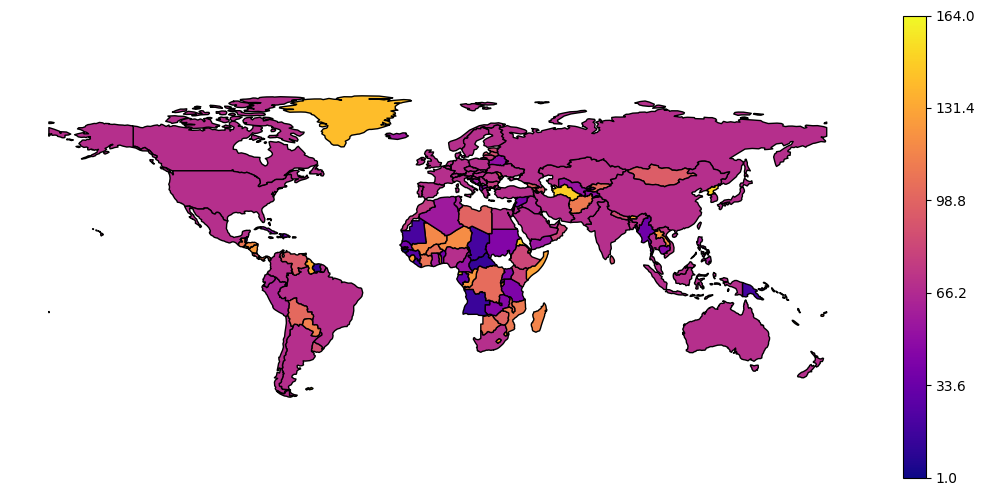

In [24]:
uf.plot_map_continuous(df_map, "cluster", country_column="country")